# PINN per l'Equazione di Burgers: Formazione di un'Onda d'Urto

Questo notebook modella la formazione e dissipazione di un'onda d'urto utilizzando l'**Equazione di Burgers Viscosa 1D**, il benchmark matematico fondamentale per l'aerodinamica transonica e la gasdinamica.

### L'Equazione
L'equazione modella la competizione tra il **steepening convettivo non-lineare** (che crea lo shock) e la **dissipazione viscosa**:
$$ \frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2} $$

* $u(x,t)$: Velocità del fluido.
* $\nu = 0.01 / \pi$: Viscosità cinematica (volutamente bassissima per innescare uno shock netto).
* **IC (Condizione Iniziale):** $u(x,0) = -\sin(\pi x)$. Un'onda dolce che collasserà al centro.
* **BC (Condizioni al Contorno):** $u(-1,t) = u(1,t) = 0$.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo in uso: {device}")

Dispositivo in uso: cuda


In [2]:
class PINN_Burgers(nn.Module):
    def __init__(self):
        super(PINN_Burgers, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 40), nn.Tanh(),
            nn.Linear(40, 40), nn.Tanh(),
            nn.Linear(40, 40), nn.Tanh(),
            nn.Linear(40, 40), nn.Tanh(),
            nn.Linear(40, 1)
        )

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

def burgers_loss(model, x, t, nu):
    x.requires_grad_(True)
    t.requires_grad_(True)
    
    u = model(x, t)
    
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    
    # Il residuo di Burgers: U_t + U*U_x - nu*U_xx = 0
    f = u_t + u * u_x - nu * u_xx
    return torch.mean(f**2)

In [3]:
nu = 0.01 / np.pi
N_pde, N_bc, N_ic = 8000, 1000, 1000

# Punti interni
x_pde = (torch.rand(N_pde, 1) * 2 - 1).to(device)
t_pde = torch.rand(N_pde, 1).to(device)

# Initial Condition: onda sinusoidale (t=0)
x_ic = (torch.rand(N_ic, 1) * 2 - 1).to(device)
t_ic = torch.zeros(N_ic, 1).to(device)
u_ic_true = -torch.sin(np.pi * x_ic)

# Boundary Conditions: fermo ai bordi (x=-1, x=1)
t_bc = torch.rand(N_bc, 1).to(device)
x_bc = torch.cat([-torch.ones(N_bc//2, 1), torch.ones(N_bc//2, 1)]).to(device)
u_bc_true = torch.zeros(N_bc, 1).to(device)

# Modello e Ottimizzatore
model = PINN_Burgers().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)

epochs = 2500
for epoch in range(epochs):
    optimizer.zero_grad()
    
    loss_pde = burgers_loss(model, x_pde, t_pde, nu)
    loss_ic = torch.mean((model(x_ic, t_ic) - u_ic_true)**2)
    loss_bc = torch.mean((model(x_bc, t_bc) - u_bc_true)**2)
    
    loss = loss_pde + loss_ic + loss_bc
    loss.backward()
    optimizer.step()
    
    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Total Loss: {loss.item():.5f} | PDE Loss: {loss_pde.item():.5f}")

print("Addestramento Completato!")

c:\Users\aless\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch    0 | Total Loss: 0.51375 | PDE Loss: 0.00013
Epoch  500 | Total Loss: 0.09399 | PDE Loss: 0.03863
Epoch 1000 | Total Loss: 0.08185 | PDE Loss: 0.03181
Epoch 1500 | Total Loss: 0.07146 | PDE Loss: 0.02713
Epoch 2000 | Total Loss: 0.04353 | PDE Loss: 0.02388
Addestramento Completato!


Generazione dell'animazione dello shock...


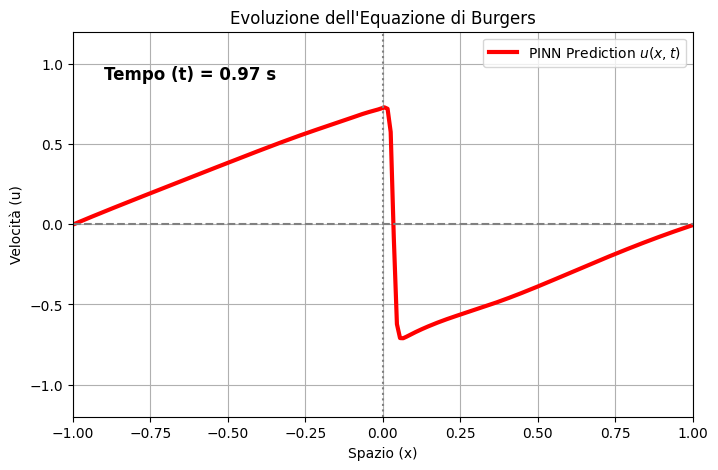

In [4]:
x_test = torch.linspace(-1, 1, 200).view(-1, 1).to(device)

fig, ax = plt.subplots(figsize=(8, 5))
line, = ax.plot([], [], 'r-', lw=3, label=r'PINN Prediction $u(x,t)$')
ax.set_xlim(-1, 1)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel('Spazio (x)')
ax.set_ylabel('Velocità (u)')
ax.axhline(0, color='gray', linestyle='--')
ax.axvline(0, color='gray', linestyle=':')
ax.legend(loc='upper right')
ax.grid(True)

time_text = ax.text(-0.9, 0.9, '', fontsize=12, fontweight='bold')

def update(frame):
    t_val = frame / 40.0  # Animazione più fluida (40 frame)
    t_test = (torch.ones_like(x_test) * t_val).to(device)
    
    with torch.no_grad():
        u_pred = model(x_test, t_test).detach().cpu().numpy()
        
    line.set_data(x_test.cpu().numpy(), u_pred)
    time_text.set_text(f'Tempo (t) = {t_val:.2f} s')
    
    # Cambia il colore del testo per enfatizzare lo shock a t=0.3 - 0.4
    if 0.25 < t_val < 0.45:
        time_text.set_color('red')
        ax.set_title("Formazione dell'Onda d'Urto (Shock steepening)!")
    else:
        time_text.set_color('black')
        ax.set_title("Evoluzione dell'Equazione di Burgers")
        
    return line, time_text

print("Generazione dell'animazione dello shock...")
ani = animation.FuncAnimation(fig, update, frames=40, interval=100, blit=True)
ani.save('burgers_shock_wave.gif', writer='pillow')

HTML(ani.to_jshtml())